# Create a Polycrystal with Elongated Grains for the Grid Solver
* Contributor: Martin Diehl (https://martin-diehl.net)
* DAMASK version: 3.1.0

In [1]:
%matplotlib inline

In [2]:
import itertools
import damask
import numpy as np
from matplotlib import pyplot as plt

In [3]:
size = np.ones(3)*1e-5
cells = [64,64,64]
ratio = [3,1,1] # use [1,1,.3] for flattened grains, [3,1,.3] for a rolling-like structure
N_grains = 400

## Procedure
Elongated grains are created from a standard Voronoi tesselation on an extended domain that is then "compressed" by decreasing its length and resolution.

In [4]:
size_extended = size/ratio
cells_extended = (np.asarray(cells)/ratio).astype(int)
seeds = damask.seeds.from_random(size_extended,N_grains,cells_extended,rng_seed=20191102)
grid = damask.GeomGrid.from_Voronoi_tessellation(cells_extended,size_extended,seeds)
grid = grid.scale(cells)
grid.size = size
grid.save(f'elongated_polycrystal_{N_grains}_{cells[0]}x{cells[1]}x{cells[2]}')
print(grid)

cells:  64 × 64 × 64
size:   1e-05 × 1e-05 × 1e-05 m³
origin: 0.0   0.0   0.0 m
# materials: 400


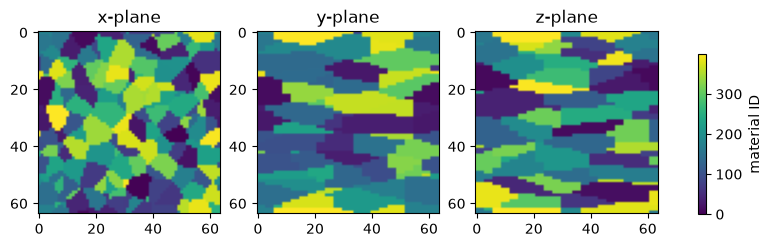

In [5]:
fig, axes = plt.subplots(figsize=(8, 8),ncols=3)
planes = ['x','y','z']
for i, plane in enumerate(planes):
    selection = [slice(None)]*3
    selection[planes.index(plane)] = 1
    im = axes[i].imshow(grid.material[tuple(selection)].T,vmin=0,vmax=N_grains-1)
    axes[i].set_title(f'{plane}-plane')
cbar_location = fig.add_axes([.95, 0.38, 0.01, 0.2])
cbar = fig.colorbar(im, cax=cbar_location)
cbar.ax.set_ylabel('material ID', rotation=90)
plt.show()